# <span style="color:darkblue"> Assignment 4  </span>

<font size = "5">

In [1]:
# import library
import pandas as pd
import matplotlib.pyplot as plt
import re


# <span style="color:darkgreen"> Descriptives  </span>

<font size = "5">

In [2]:
# Read data
bills_actions = pd.read_csv("data_raw/bills_actions.csv")

# Descriptives
# Check the sample size and numbers of variables
print(bills_actions.shape)

# The value types of variables 
print(bills_actions.dtypes)

# If the dataset has missing values
print(bills_actions.isna().sum())


(3303, 7)
Congress        int64
bill_number     int64
bill_type      object
action         object
main_action    object
category       object
member_id       int64
dtype: object
Congress       0
bill_number    0
bill_type      0
action         0
main_action    0
category       0
member_id      0
dtype: int64


In [3]:
# EXISTING bill identifier: bill_number
bills_actions["bill_number"].value_counts()

bill_number
2740    243
3055    187
2500     96
1        75
1585     46
       ... 
127       1
125       1
19        1
16        1
695       1
Name: count, Length: 1331, dtype: int64

In [5]:
# Create NEW bill identifier = bill_number + bill_type
bills_actions["bill_id"] = (bills_actions["bill_type"] + bills_actions["bill_number"].astype(str))
bills_actions["bill_id"].value_counts()

bill_id
hr2740     242
hr3055     187
hr2500      96
hr1         62
hr1585      46
          ... 
hres576      1
s2769        1
s2779        1
hres552      1
s1029        1
Name: count, Length: 1494, dtype: int64

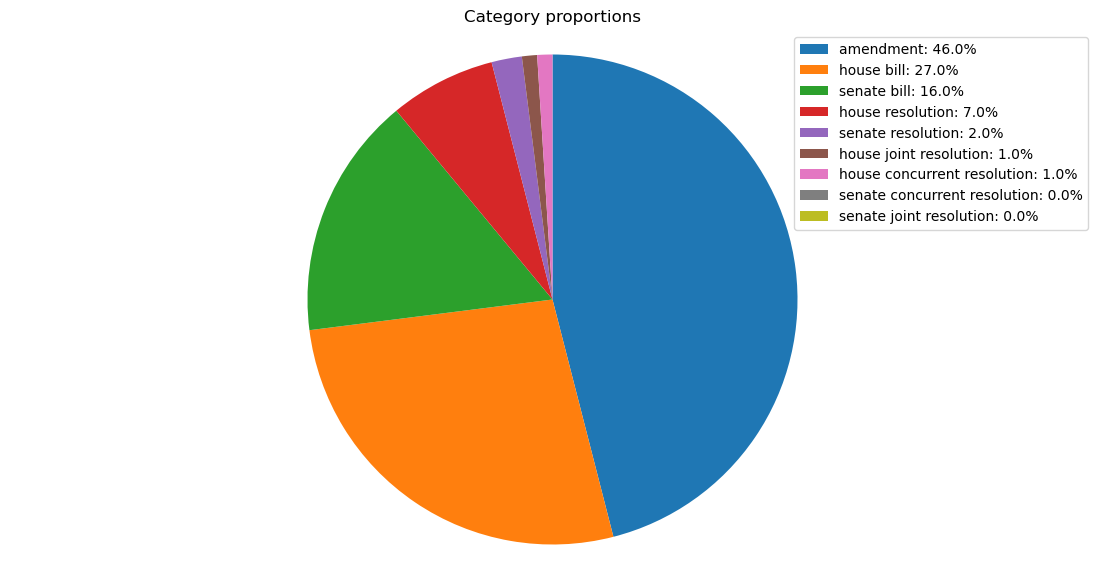

In [6]:
# Calculate proportion of the rows belong to different categories
cat_prop = bills_actions["category"].value_counts(normalize=True).round(2)
# create a new column: category proportions
bills_actions["cat_p"] = bills_actions["category"].map(cat_prop)

# Draw pie chart for categories
plt.figure(figsize=(14, 7))
plt.pie(cat_prop.values,
        labels=None,
        autopct=None,
        startangle=90,
        counterclock=False
        )
plt.title("Category proportions")
legend_labels = [f"{label}: {value:.1%}" for label, value in cat_prop.items()]
plt.legend(legend_labels, loc="upper right")
plt.axis("equal")
plt.show()

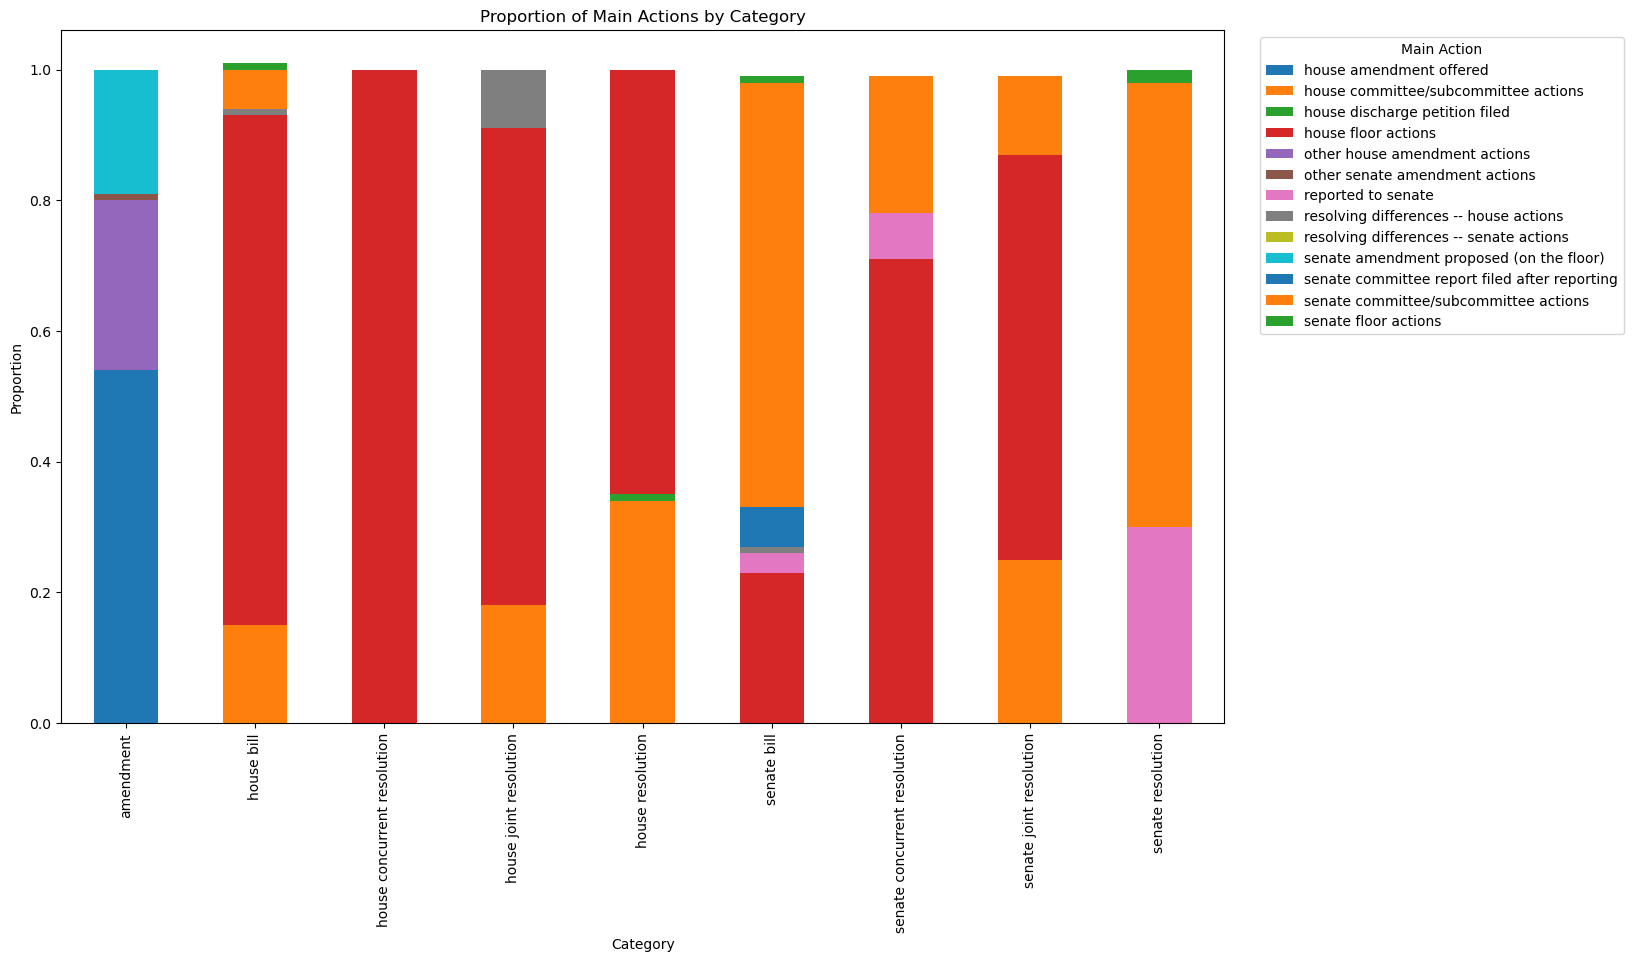

In [7]:
# In each category,
# calculate the proportion of different "main_action"
categaction = pd.crosstab(
    bills_actions["category"],
    bills_actions["main_action"],
    normalize="index").round(2)

# Draw stacked plot diagram
categaction.plot(kind='bar', stacked=True, figsize=(15, 9))
plt.title("Proportion of Main Actions by Category")
plt.xlabel("Category")
plt.ylabel("Proportion")
plt.legend(title="Main Action", bbox_to_anchor=(1.35, 1), loc='upper right')
plt.show()

In [8]:
# Count house floor actions in senate bills
senate_bills = bills_actions.query('category == "senate bill"')
house = senate_bills.query('main_action == "house floor actions"')
len(house)

116

In [8]:
#test_suspend = senate_bills[senate_bills["action"].str.contains(r"suspend")]
#test_suspend1 = senate_bills[senate_bills["action"].str.contains(r"\b(?:suspend(?:ed|s|ing)?|suspension)\b")]
#test_suspend1
#act_amend = house[house["action"].str.contains('amend')]
#act_amend
house

,Congress,bill_number,bill_type,action,main_action,category,member_id,bill_id,cat_p
559,116,1436,s,Ms. Lofgren asked unanimous consent to take fr...,house floor actions,senate bill,1230,s1436,0.16
560,116,1693,s,Mr. Evans asked unanimous consent to take from...,house floor actions,senate bill,1395,s1693,0.16
562,116,1749,s,Mr. Clay asked unanimous consent to discharge ...,house floor actions,senate bill,1806,s1749,0.16
563,116,2047,s,Ms. DeGette asked unanimous consent to take fr...,house floor actions,senate bill,294,s2047,0.16
564,116,2249,s,Mr. Larsen (WA) asked unanimous consent to dis...,house floor actions,senate bill,963,s2249,0.16
...,...,...,...,...,...,...,...,...,...
790,116,906,s,Mr. Huffman moved to suspend the rules and pas...,house floor actions,senate bill,527,s906,0.16
792,116,945,s,Mr. Clay moved to suspend the rules and pass t...,house floor actions,senate bill,1806,s945,0.16
794,116,979,s,Ms. Norton moved to suspend the rules and pass...,house floor actions,senate bill,346,s979,0.16
796,116,982,s,Ms. Scanlon moved to suspend the rules and pas...,house floor actions,senate bill,792,s982,0.16


In [9]:
# Calculate proportion of suspended actions
act_suspend = house[house["action"].str.contains("suspend")]
suspend_prop = len(act_suspend)/len(house)

# Calculate proportion of amended actions
act_amend = house[house["action"].str.contains('amend')]
amend_prop = len(act_amend)/len(house)

In [ ]:
#house["action"].str.findall(r"(?:Mr\.|Mrs\.|Ms\.) \w*")
#Extract name from house floor actions data
name_action = house["action"].str.findall(r"(?:Mr\.|Mrs\.|Ms\.)\s[A-Z][a-zA-Z-]+(?:\s[A-Z][a-zA-Z-]+)*")

bill_id = (bills_actions["bill_type"] + bills_actions["bill_number"].astype(str))

# Convert to a new dataset
# first we convert the name list to name string
# namedata = pd.DataFrame(name_action.explode().value_counts())
person_data = (
    pd.DataFrame({"bill_id": bill_id, "person": name_action})
      .explode("person")
      .dropna()
      .drop_duplicates(subset=["bill_id", "person"])
)
person_data


,bill_id,person
559,s1436,Ms. Lofgren
560,s1693,Mr. Evans
562,s1749,Mr. Clay
563,s2047,Ms. DeGette
564,s2249,Mr. Larsen
...,...,...
790,s906,Mr. Huffman
792,s945,Mr. Clay
794,s979,Ms. Norton
796,s982,Ms. Scanlon


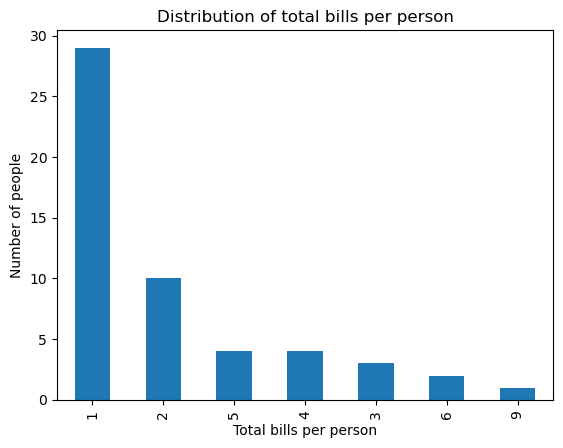

In [16]:
# Counting how many bills mention the same person
per_person = (person_data.groupby("person")["bill_id"]
              .nunique()
              .reset_index(name="bills_num")
              .sort_values("bills_num", ascending=False))

# Draw plot
per_person["bills_num"].value_counts().plot(kind="bar")
plt.xlabel("Total bills per person")
plt.ylabel("Number of people")
plt.title("Distribution of total bills per person")
plt.show()


/var/folders/9m/zg5r48150372jl9972nmv_q00000gn/T/ipykernel_18440/2116673701.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amend_floor["senators_perbill"] = amend_floor["action"].str.findall(r"\bSenator\s[A-Z][a-zA-Z-]+(?:\s[A-Z][a-zA-Z-]+)*")


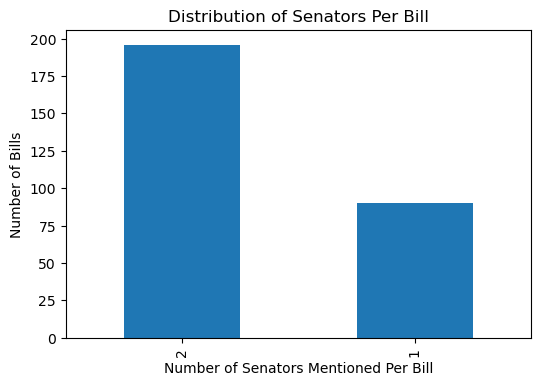

In [17]:
# Subset actions: "senate amendment proposed(on the floor)”
amend_floor = bills_actions.query('main_action == "senate amendment proposed (on the floor)"')

# Create a dataset names of senators per bill 
# Extract senators' names
amend_floor["senators_perbill"] = amend_floor["action"].str.findall(r"\bSenator\s[A-Z][a-zA-Z-]+(?:\s[A-Z][a-zA-Z-]+)*")

senators = pd.DataFrame({
    "bill_id": amend_floor["bill_id"],
    "senators_num": amend_floor["senators_perbill"].str.len(),
    "senator1": amend_floor["senators_perbill"].str[0],
    "senator2": amend_floor["senators_perbill"].str[1],
})

# Draw graph the distribution of senator number
senators["senators_num"].value_counts().plot(kind="bar", figsize=(6,4))
plt.xlabel("Number of Senators Mentioned Per Bill")
plt.ylabel("Number of Bills")
plt.title("Distribution of Senators Per Bill")
plt.show()



In [18]:
#
coauthors = (
    senators
       .groupby("senator1")["senator2"].nunique()
       .reset_index(name="coauthors_num")
       .sort_values("coauthors_num", ascending=False)
)
coauthors

,senator1,coauthors_num
14,Senator McConnell,57
23,Senator Reed,25
2,Senator Cornyn,9
3,Senator Cramer,7
18,Senator Murkowski,6
0,Senator Braun,5
17,Senator Moran,4
35,Senator Thune,3
13,Senator Lee,3
26,Senator Sasse,2
